In [128]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# remove warnings
import warnings
warnings.filterwarnings("ignore")

##### *1. Data Import*


In [129]:
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

tables=pd.read_sql(sql_query,conn)

#create dataframe for each table

for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Crated Data Frame:df_{table_name}")

conn.close()



Crated Data Frame:df_db_customer
Crated Data Frame:df_db_subscription
Crated Data Frame:df_db_support


In [130]:
#print table names and columns names 

conn=sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [131]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


##### *2. Data Cleaning*

In [132]:
df_db_customer.head()  #customer table

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [133]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [134]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [135]:
# a. rename column - name
# b. drop columns - pincode, intrests
# c. change data typr of - DOB
# d. data standardize - gender col
# f. fix missing values of country


In [136]:
# a. rename column - name
df_db_customer.rename(columns={'name':'customer_name'}, inplace=True)

In [137]:
# b. drop columns - pincode, intrests
df_db_customer.drop(['pincode','interests'],axis=1,inplace=True)

In [138]:
# c. change data typr of - DOB
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [139]:
# d. data standardize - gender col
df_db_customer['gender'].unique()
df_db_customer['gender'].replace({'Women':"Female",'Men':'Male'},inplace=True)

In [140]:
# f. fix missing values of country

#checking null values 
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [141]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [142]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [143]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [144]:
df_db_subscription.head() #subscription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [145]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,None,None,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,None,None,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,None,None,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,None,None,13.99,790,47


In [146]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [147]:
#change data type of all date col 

date_col=['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [148]:
df_db_support.head() #cutomer support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [149]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [150]:
#dropping unwanted columns

df_db_support.drop(columns=['col_1','comment'],axis=1,inplace=True)


In [151]:
df_db_support.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score'], dtype='object')

In [152]:
#changing the data type of complaint_date  col

df_db_subscription['cancellation_date']=pd.to_datetime(df_db_subscription['cancellation_date'])

In [153]:
df_db_subscription['cancellation_date'].dtype

dtype('<M8[ns]')

#### *3. Feature Engineering and Data Analysis*

In [154]:
#churn flag

df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [155]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [156]:
#merging all 3 tables into one table 

df=(df_db_subscription.merge(df_db_customer, on='customerid', how='left')
                    .merge(df_db_support, on='customerid', how='left'))

In [157]:
df.size

460

In [158]:
df.shape  # 2 rows are extra in this comabine table 

(23, 20)

In [159]:
df_db_subscription.shape

(21, 12)

In [160]:
df_db_subscription['customerid'].nunique()

21

In [161]:
df_db_customer['customerid'].nunique()

21

In [162]:
df_db_support['customerid'].nunique()

7

In [163]:
df_db_support['customerid'].size

9

In [164]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [165]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [166]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,1
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,1
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,2
8,0022-TCJCI,2024-09-14 00:00:00,N,90,2
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,1
4,0013-SMEOE,2024-11-01 00:00:00,N,30,1
3,0013-MHZWF,2025-03-18 00:00:00,N,90,1


In [167]:
#remerged because there where duplicates in support table

df=(df_db_subscription.merge(df_db_customer, on='customerid', how='left')
                    .merge(df_db_support, on='customerid', how='left'))

In [168]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28 00:00:00,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20 00:00:00,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,0,durga,India,Delhi,Female,1988-12-10,2025-03-18 00:00:00,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01 00:00:00,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaN,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaN,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaN,NaN,NaN,NaN


In [169]:
df.shape

(21, 21)

In [170]:
df.to_csv('exported_churn_data.csv', index=False)

In [171]:
#data analysis

In [172]:
# Churn rate

churn_rate=df['churn_flag'].mean()*100
print(f"churn_rate : {round(churn_rate,2)}")


churn_rate : 28.57


In [173]:
# Retention rate

retention_rate=100-churn_rate
print(f"retention_rate : {round(retention_rate,2)}")

retention_rate : 71.43


In [174]:
# Churn by Plan type

churn_by_plam=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
churn_by_plam

,plan_type,churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [175]:
# 4 a. Churn by state + sum(revenue) & count of users  
churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('customerid', 'count')
      )
      .reset_index()
      .sort_values(by='churn_rate_pct', ascending=False)
)

print(churn_by_state)

# 4 b. Churn by subscription type + sum(revenue) & count of users   

churn_by_subscription_type=(
    df.groupby('subscription_type').agg(
          churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
          total_revenue=('monthly_charges', 'sum'),
          user_count=('customerid', 'count')
      ).reset_index()
      .sort_values(by='churn_rate_pct', ascending=False)
)

print()

print(churn_by_subscription_type)


           state  churn_rate_pct  total_revenue  user_count
1      Karnataka          100.00          20.98           2
4      Meghalaya           66.67          42.97           3
7      Telangana           50.00          30.98           2
0          Delhi           25.00          52.96           4
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
8  Uttar Pradesh            0.00         115.98           2

  subscription_type  churn_rate_pct  total_revenue  user_count
2          Refferal           83.33          74.94           6
1              Paid           16.67         174.94           6
0           Organic            0.00         145.91           9


In [176]:
# ARPU Average Revenue per User
arpu=df['monthly_charges'].mean()
arpu.round(2)

np.float64(18.85)

In [177]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [178]:
#6. Average Customer Tenure
# that is count of days user has used our service : cancellation date else current date

#fisrt create a col and calculate tenure days 
#after that use that column to calculate Average Customer Tenure

today=pd.Timestamp.today()

df['tenure_days']=np.where(
    df['cancellation_date'].notna(), #condition 
    (df['cancellation_date']-df['subscription_start_date']).dt.days, # true
    (today-df['subscription_start_date']).dt.days  #false
)

# Average Customer Tenure

average_tenure=df['tenure_days'].mean().round(0)
print(average_tenure)

1499.0


In [179]:
#7. Revenue at Risk or Revenue lost from churned users

revenue_at_risk=df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print(f'Revenue at Risk is {revenue_at_risk} k')

Revenue at Risk is 73.94 k


In [180]:
#8. Esclation Rate
esclation_rate=(df['escalations']=='Y').mean()*100
print(f"Esclation rate is {round(esclation_rate,2)} %")

Esclation rate is 19.05 %


In [181]:
#9. Average Complaint Per User
avg_complaint_per_user = df['complaint_count'].sum() / df['customerid'].nunique()
print(f"Average Complaint Per User is  {round(avg_complaint_per_user,2)}")

Average Complaint Per User is  0.43


In [182]:
#10. Correlation Eclastion VS Churn

df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()


In [183]:
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.77


In [184]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [185]:
# 11. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

##### *4. Data Visualization*

In [186]:
df_visuals=df.copy()

In [187]:
# Monthely Churn Trend using matplotlib

df_visuals['cancellation_month']=df_visuals['cancellation_date'].dt.to_period('M')

churn_trend=df_visuals[df_visuals['churn_flag']==1].groupby('cancellation_month').size() #return series
# .size() counts all rows, including rows with null values.
# .count() counts non-null values column-wise

# Number of rows in each group → use .size()
# Number of non-null values in a column → use .count()

# churn_trend.index
#      ↓
# ['2024-02',
#  '2024-05',
#  '2024-09',
#  '2024-10',
#  '2024-11']

# churn_trend.values
#       ↓
# [1, 1, 2, 1, 1]

# print(churn_trend)


# plt.figure(figsize=(8,3))
# plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed')
# plt.title('Monthely Trend')
# plt.xlabel('Month')
# plt.ylabel('Churned Customers')

<function matplotlib.pyplot.show(close=None, block=None)>

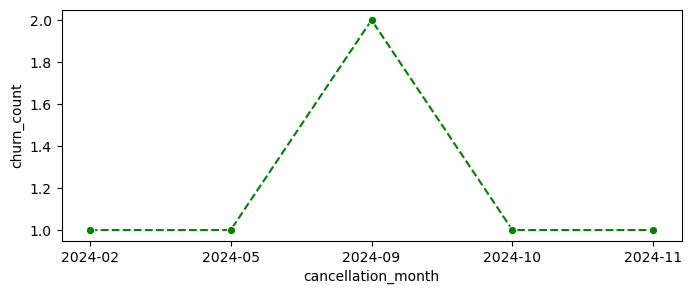

In [188]:
# 4.1 Monthely Churn Trend

churn_trends = churn_trend.reset_index(name='churn_count') # convert series into data frame using reset_index
# Without reset_index(name='churn_count'), there is no churn_count column

churn_trends['cancellation_month']=churn_trends['cancellation_month'].astype(str)

plt.figure(figsize=(8,3))

sns.lineplot(data=churn_trends, x='cancellation_month', y='churn_count', marker='o', color="green", linestyle="dashed")

plt.show


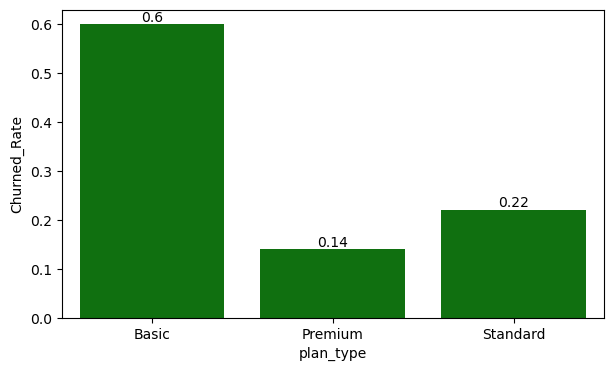

In [189]:
# 4.2 Churned by plan type

plt.figure(figsize=(7,4))

churn_plan=df_visuals.groupby('plan_type')['churn_flag'].mean().round(2).reset_index(name='Churned_Rate')

ax=sns.barplot(data=churn_plan,x='plan_type', y='Churned_Rate', color='green')

for container in ax.containers:
    ax.bar_label(container)


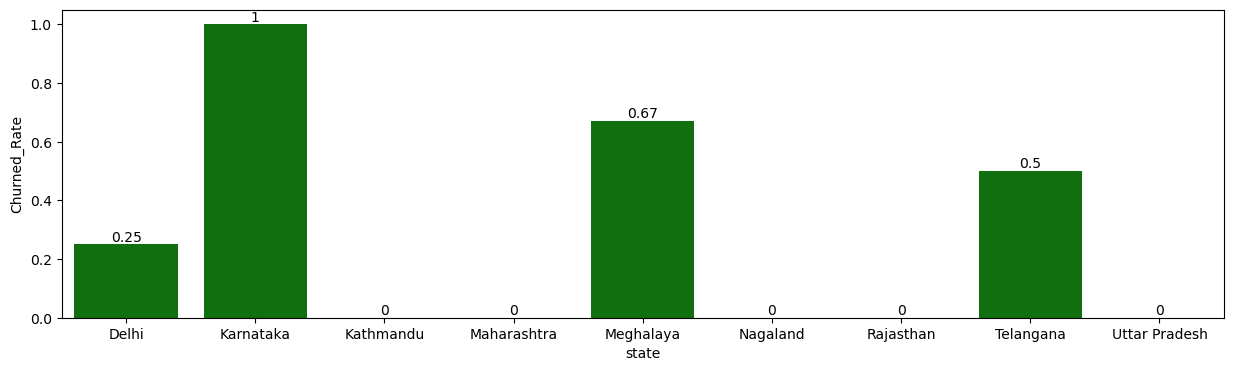

In [190]:
# 4.3 Churn by State


plt.figure(figsize=(15,4))

churn_plan=df_visuals.groupby('state')['churn_flag'].mean().round(2).reset_index(name='Churned_Rate')

ax=sns.barplot(data=churn_plan,x='state', y='Churned_Rate', color='green')

for container in ax.containers:
    ax.bar_label(container)


In [191]:
# 4.4 HeatMap

# encoding - convert str to numeric so that we can find corr between features
df_visuals.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [192]:
df_visuals[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [ ]:
# incorrect method of encoding - as numbers are not assigned based on priority
# df_encoded = df_visuals[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

# categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

# for col in categorial_cols:
#     df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [196]:
# Heatmap (correlation matrix)

# sns.heatmap(df_encoded.corr(), annot=True)

In [197]:
df_encoded = df_visuals[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [198]:
df_visuals[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [199]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

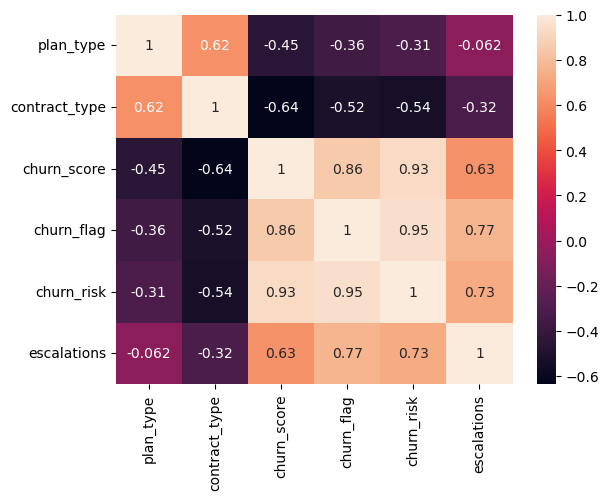

In [200]:
sns.heatmap(df_encoded.corr(), annot=True)

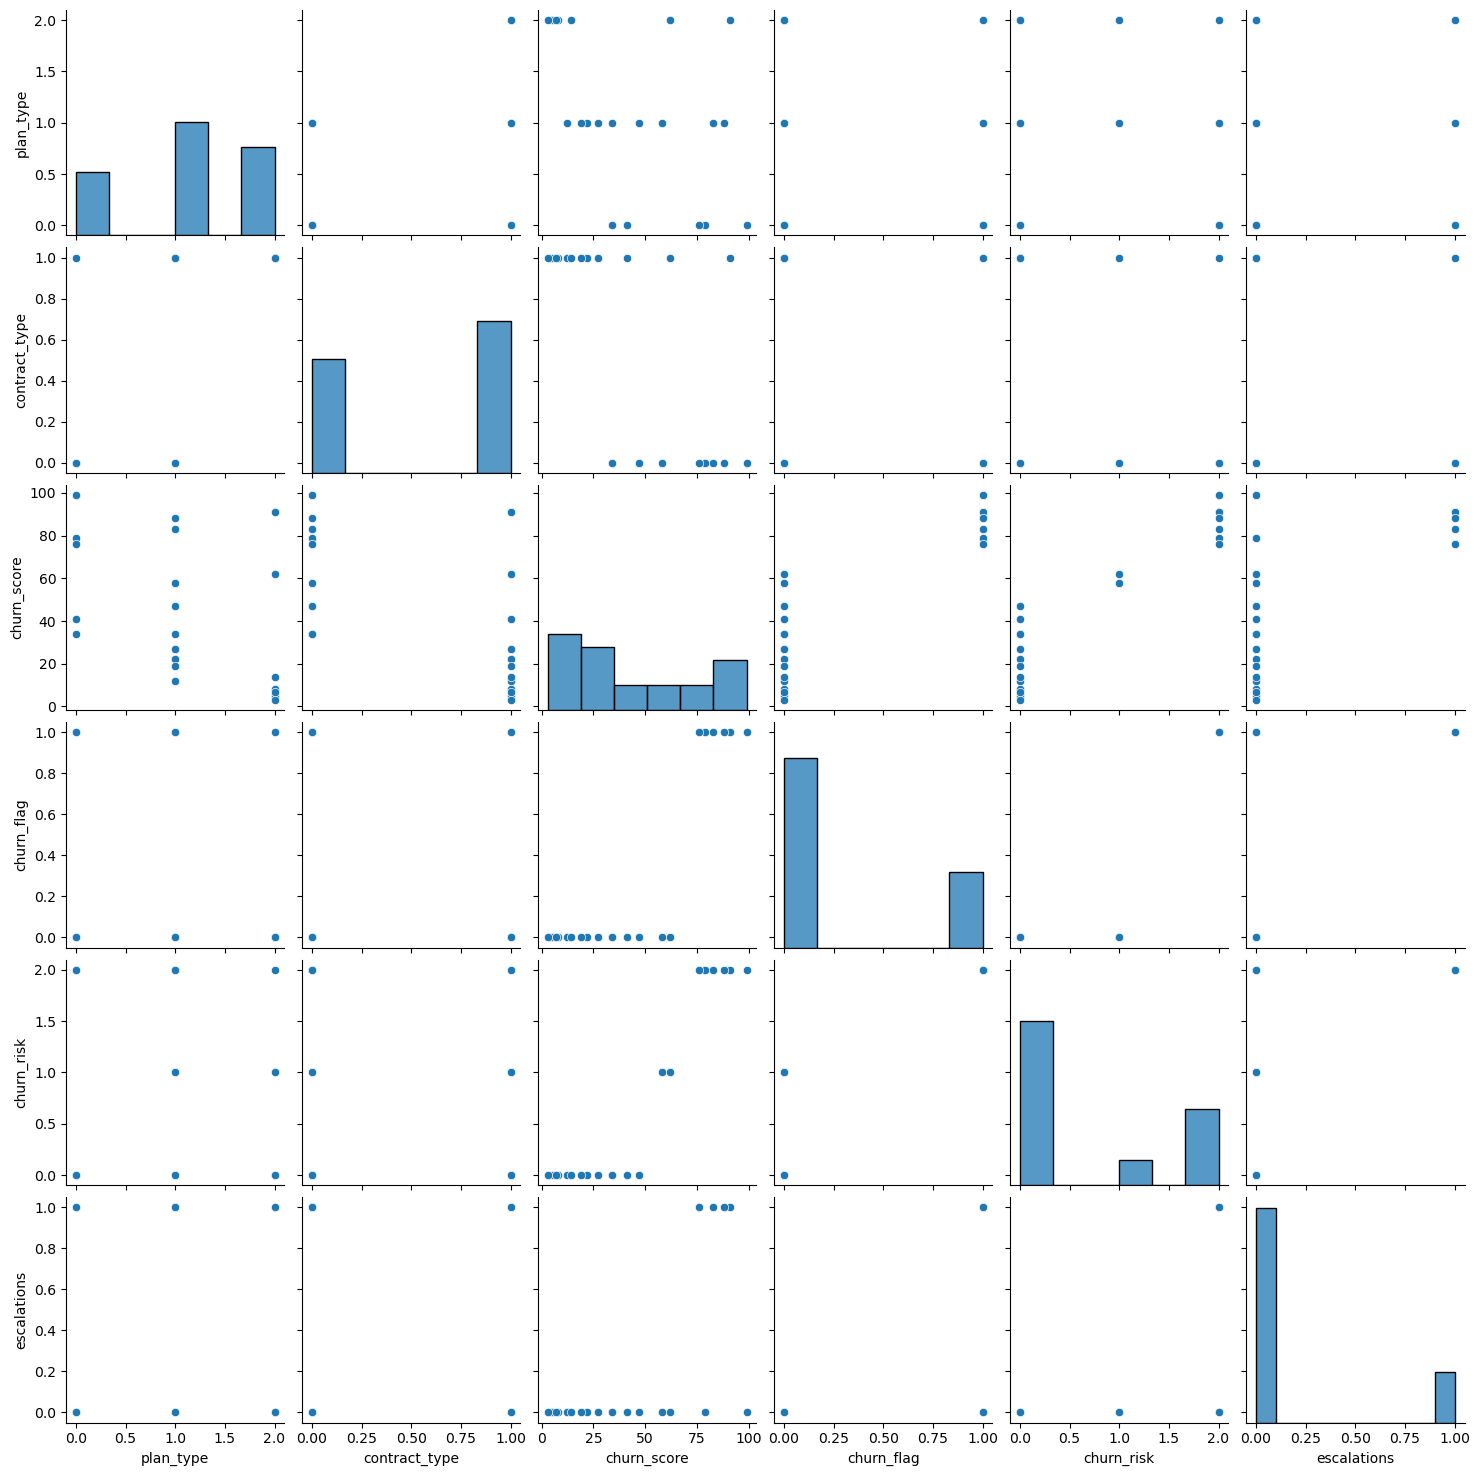

In [201]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

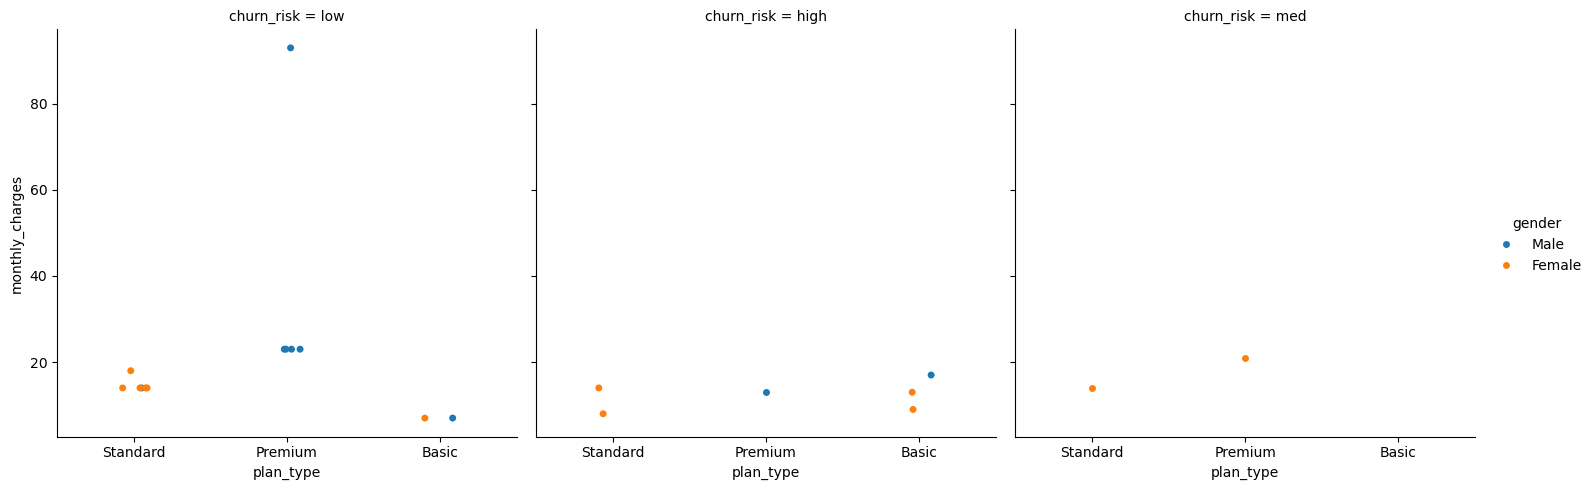

In [203]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visuals,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [204]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visuals,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
df_visuals.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')